In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.metrics import r2_score

# Load Dataset

In [2]:
df = pd.read_csv("LGD.csv")
df

,Ac_No,Age,Years of Experience,Number of Vehicles,Gender,Married,Losses in Thousands
0,150024,24,5,1,M,Married,203.319595
1,144880,31,10,1,F,Single,402.197302
2,133742,56,37,1,M,Married,553.132096
3,151282,52,31,1,F,Married,292.430579
4,174407,20,3,1,M,Single,246.540576
...,...,...,...,...,...,...,...
15285,189499,61,43,4,F,Single,58.426429
15286,142111,69,48,4,F,Married,304.519134
15287,176444,69,51,4,F,Married,282.149148
15288,180420,22,4,4,M,Married,822.470554


In [3]:
df.head()

,Ac_No,Age,Years of Experience,Number of Vehicles,Gender,Married,Losses in Thousands
0,150024,24,5,1,M,Married,203.319595
1,144880,31,10,1,F,Single,402.197302
2,133742,56,37,1,M,Married,553.132096
3,151282,52,31,1,F,Married,292.430579
4,174407,20,3,1,M,Single,246.540576


In [4]:
df.tail()

,Ac_No,Age,Years of Experience,Number of Vehicles,Gender,Married,Losses in Thousands
15285,189499,61,43,4,F,Single,58.426429
15286,142111,69,48,4,F,Married,304.519134
15287,176444,69,51,4,F,Married,282.149148
15288,180420,22,4,4,M,Married,822.470554
15289,157201,20,2,4,F,Married,406.924740


In [5]:
df.describe()

,Ac_No,Age,Years of Experience,Number of Vehicles,Losses in Thousands
count,15290.000000,15290.000000,15290.000000,15290.000000,15290.000000
mean,149961.789339,42.328254,23.732897,2.495880,389.859718
std,28947.841061,18.280511,17.850707,0.953776,253.729433
min,100002.000000,16.000000,0.000000,1.000000,12.534521
25%,124900.500000,24.000000,6.000000,2.000000,226.434217
50%,149897.500000,42.000000,23.000000,2.000000,354.937874
75%,175019.500000,61.000000,42.000000,3.000000,488.676927
max,200454.000000,70.000000,53.000000,4.000000,3500.000000


In [6]:
df.describe(include="object")

,Gender,Married
count,15290,15290
unique,2,2
top,F,Married
freq,7747,7783


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15290 entries, 0 to 15289
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Ac_No                15290 non-null  int64  
 1   Age                  15290 non-null  int64  
 2   Years of Experience  15290 non-null  int64  
 3   Number of Vehicles   15290 non-null  int64  
 4   Gender               15290 non-null  object 
 5   Married              15290 non-null  object 
 6   Losses in Thousands  15290 non-null  float64
dtypes: float64(1), int64(4), object(2)
memory usage: 836.3+ KB


In [8]:
df.shape

(15290, 7)

# Data Cleaning

In [9]:
df.isnull()

,Ac_No,Age,Years of Experience,Number of Vehicles,Gender,Married,Losses in Thousands
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
15285,False,False,False,False,False,False,False
15286,False,False,False,False,False,False,False
15287,False,False,False,False,False,False,False
15288,False,False,False,False,False,False,False


In [10]:
df.isnull().sum()

Ac_No                  0
Age                    0
Years of Experience    0
Number of Vehicles     0
Gender                 0
Married                0
Losses in Thousands    0
dtype: int64

In [11]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
15285    False
15286    False
15287    False
15288    False
15289    False
Length: 15290, dtype: bool

In [12]:
df.duplicated().sum()

0

# EDA

<Axes: xlabel='Losses in Thousands'>

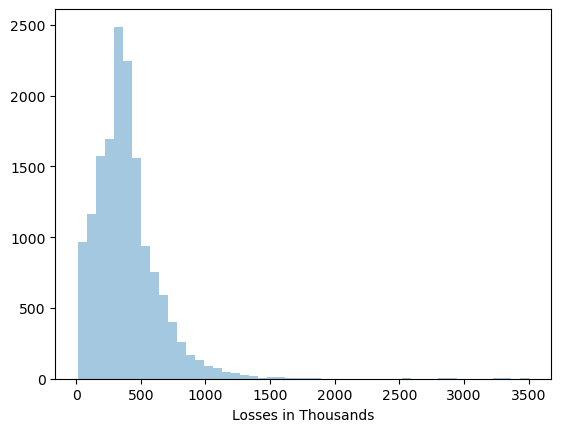

In [13]:
sns.distplot(df["Losses in Thousands"], kde=False, bins=50)

<Axes: xlabel='Age'>

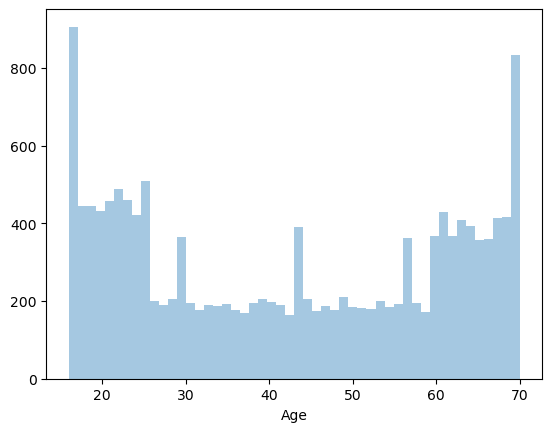

In [14]:
sns.distplot(df["Age"], kde=False, bins=50)

<Axes: xlabel='Years of Experience', ylabel='Density'>

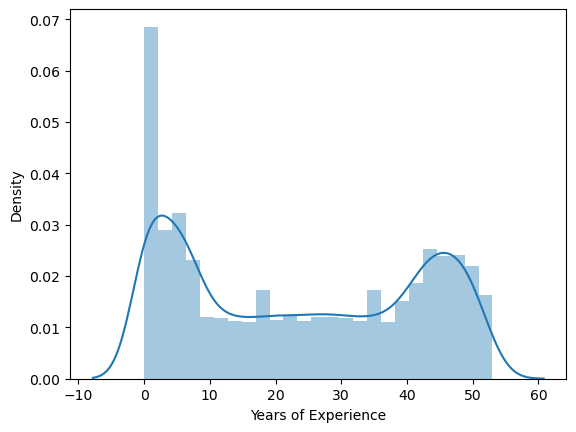

In [15]:
sns.distplot(df["Years of Experience"], kde=True, bins=25)

<Axes: xlabel='Married', ylabel='Losses in Thousands'>

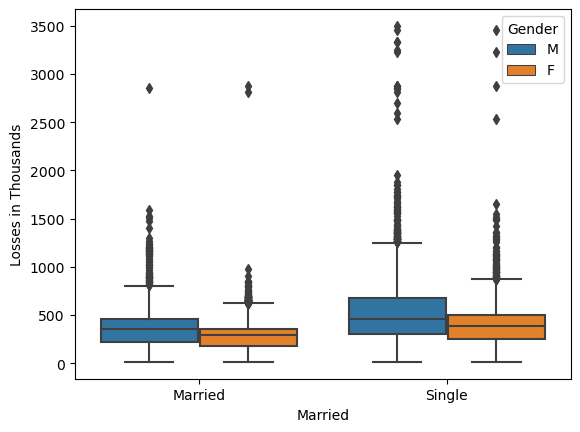

In [16]:
sns.boxplot(x="Married", y="Losses in Thousands", data=df, hue="Gender")

In [17]:
df.corr()

,Ac_No,Age,Years of Experience,Number of Vehicles,Losses in Thousands
Ac_No,1.000000,0.008291,0.008437,-0.003056,-0.000794
Age,0.008291,1.000000,0.997161,0.008366,-0.442962
Years of Experience,0.008437,0.997161,1.000000,0.008545,-0.442115
Number of Vehicles,-0.003056,0.008366,0.008545,1.000000,-0.011553
Losses in Thousands,-0.000794,-0.442962,-0.442115,-0.011553,1.000000


# Deriving new features

In [18]:
gender_dummies = pd.get_dummies(df["Gender"], drop_first=True)
gender_dummies.columns = ["Male"]
df = pd.concat([df, gender_dummies], axis=1)

In [19]:
df.head()

,Ac_No,Age,Years of Experience,Number of Vehicles,Gender,Married,Losses in Thousands,Male
0,150024,24,5,1,M,Married,203.319595,1
1,144880,31,10,1,F,Single,402.197302,0
2,133742,56,37,1,M,Married,553.132096,1
3,151282,52,31,1,F,Married,292.430579,0
4,174407,20,3,1,M,Single,246.540576,1


In [20]:
gender_dummies = pd.get_dummies(df["Married"], drop_first=True)
gender_dummies.columns = ["Single"]
df = pd.concat([df, gender_dummies], axis=1)

In [21]:
df.head()

,Ac_No,Age,Years of Experience,Number of Vehicles,Gender,Married,Losses in Thousands,Male,Single
0,150024,24,5,1,M,Married,203.319595,1,0
1,144880,31,10,1,F,Single,402.197302,0,1
2,133742,56,37,1,M,Married,553.132096,1,0
3,151282,52,31,1,F,Married,292.430579,0,0
4,174407,20,3,1,M,Single,246.540576,1,1


In [22]:
new_df=df.drop(['Gender', 'Married'], axis=1)

# Residual Analysis of Model

In [23]:
new_df.head()

,Ac_No,Age,Years of Experience,Number of Vehicles,Losses in Thousands,Male,Single
0,150024,24,5,1,203.319595,1,0
1,144880,31,10,1,402.197302,0,1
2,133742,56,37,1,553.132096,1,0
3,151282,52,31,1,292.430579,0,0
4,174407,20,3,1,246.540576,1,1


In [24]:
X = new_df[["Age", "Number of Vehicles", "Male", "Single"]]
Y = new_df["Losses in Thousands"]

In [25]:
X.shape

(15290, 4)

In [26]:
Y.shape

(15290,)

# Train-Test Split and feature scalling

In [27]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.7, random_state=42)
X_train.shape, X_test.shape

((10703, 4), (4587, 4))

# Model training

## 1. Linear Regression

In [28]:
regressor = LinearRegression()
regressor.fit(X_train, Y_train)

LinearRegression()

In [29]:
print("Intercept is: ",regressor.intercept_)

Intercept is:  536.3918314311628


In [30]:
print("Coefficient is: ",regressor.coef_)

Coefficient is:  [ -6.1215775    0.20975509  91.17454455 133.06754296]


In [31]:
y_pred = regressor.predict(X_test)
print(y_pred)

[474.94644854 485.7921965  223.75201578 ... 351.1174914  401.92688142
 388.07656428]


In [32]:
print("MAE is: ", metrics.mean_absolute_error(Y_test, y_pred))

MAE is:  148.4575698584855


In [33]:
print("MSE is: ", metrics.mean_squared_error(Y_test, y_pred))

MSE is:  48355.34325267157


In [34]:
print("R2 score is: ",r2_score(Y_test, y_pred))

R2 score is:  0.2961799279909947


## 2. Random Forest

In [35]:
from sklearn.ensemble import RandomForestRegressor

In [36]:
rf_regressor = RandomForestRegressor()
rf_regressor.fit(X_train, Y_train) 

RandomForestRegressor()

In [37]:
Y_pred = rf_regressor.predict(X_test)
Y_pred

array([455.96648005, 410.59412997, 236.67695649, ..., 200.48902516,
       323.90442154, 330.09013403])

In [38]:
print("MSE is: ", metrics.mean_squared_error(Y_test, Y_pred))

MSE is:  44704.755494506295


In [39]:
print("R2 score is: ",r2_score(Y_test, Y_pred))

R2 score is:  0.34931484061898277


## 3. SVM

In [40]:
from sklearn.svm import SVR

In [41]:
svm_regressor = SVR(kernel='linear')
svm_regressor.fit(X_train, Y_train)

SVR(kernel='linear')

In [42]:
svm_pred = svm_regressor.predict(X_test)

In [43]:
print("MSE is: ", metrics.mean_squared_error(Y_test, svm_pred))

MSE is:  50333.327930618994


In [44]:
print("R2 score is: ",r2_score(Y_test, svm_pred))

R2 score is:  0.2673900316771318


## 4. Decision Tree

In [45]:
from sklearn.tree import DecisionTreeRegressor  

In [46]:
regressor = DecisionTreeRegressor()  
regressor.fit(X, Y) 

DecisionTreeRegressor()

In [47]:
DT_pred = svm_regressor.predict(X_test)

In [48]:
print("MSE is: ", metrics.mean_squared_error(Y_test, DT_pred))

MSE is:  50333.327930618994


In [49]:
print("R2 score is: ",r2_score(Y_test, svm_pred))

R2 score is:  0.2673900316771318
